## Rotary Power Spectra and CTD Profiles near Terra Nova Bay 

### Rotary Power Spectra 

**Goal:** Apply correlation and spectral relations to a vector timeseries (i.e. ocean currents) that is influenced by Earth's rotation. Earth's rotation can cause an asymmetry in fourier coefficients and we seek statistical relations that are invariant to rotation. 

A given velocity can be decomposed into a real and imaginary part, 

$$ u = u + iv $$

where $ i = \sqrt{-1} $

In Gonella (1972), four quantities are deemed useful: 

1. The mean kinetic energy (i.e. the total spectrum)

2. The rotary coefficient 

3. The orientation of the ellipse 

4. The stability of the ellipse 

Expanding on these, 

The mean kinetic energy, or the total spectrum, is defined as the summation of the clockwise ($ S_{-} $) and counterclockwise ($ S_{+} $) spectrums, 

$$ S_{t} = S_{-} + S_{+} $$

The rotary coefficient is defined as, 

$$ C_{R} = (S_{-} - S_{+}) / (S_{-} + S_{+}) $$



In [1]:
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np 
from scipy.signal import welch, csd
import pandas as pd
from TNB_tools.spectra import rotary_power_spectra
import gsw


In [2]:
# load in TNBD current meter data from bottom sensor (~1130 meters)
# # MAC
# vel = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_vel_bot_1093.nc')

# DELL
vel = xr.open_dataset("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2018_19 Araon Cruise (ANA09B) - NIWAMooringRetrieval/Data/TNBD/working/tnbd_2018_vel_bot_1093.nc")


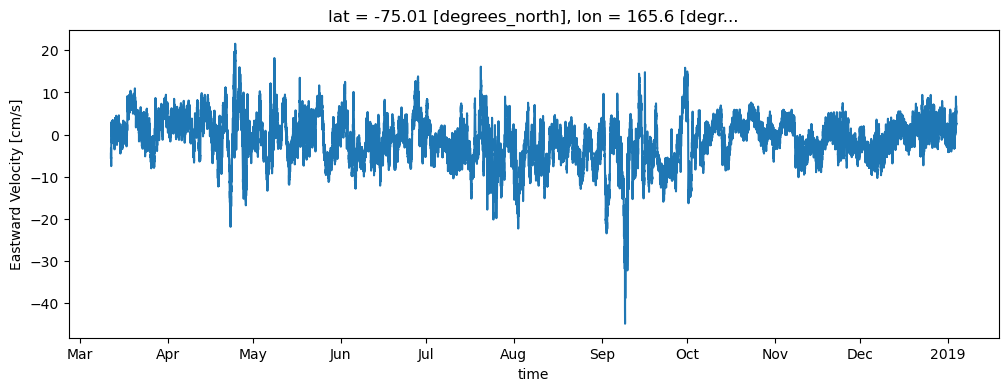

In [4]:
vel.u.plot(figsize=(12,4))

In [5]:
f = gsw.f(-75)
# intertial frequency [cpd]
f_inertial = np.abs(f) * 86400 / (2*np.pi)

In [6]:
f

np.float64(-0.0001408728441353982)

In [7]:
# step 1: define u, v, fs, and nperseg (to be used in power spectra calculation)
u = vel.u
v= vel.v
fs = 1/900 # 15 minutes
nperseg = 1024

# other nperseg values to try: 
# 5722 --> 5 segments 
# 4096 --> 13 segments 
# 2048 --> 27 segments 
# 1024 --> 55 segments 

In [8]:
# Chi - squared CI workflow 
freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(u, v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

Text(0.38, 1.02, 'K1')

C:\Users\mblan\AppData\Local\Temp\ipykernel_54016\88943626.py:16: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


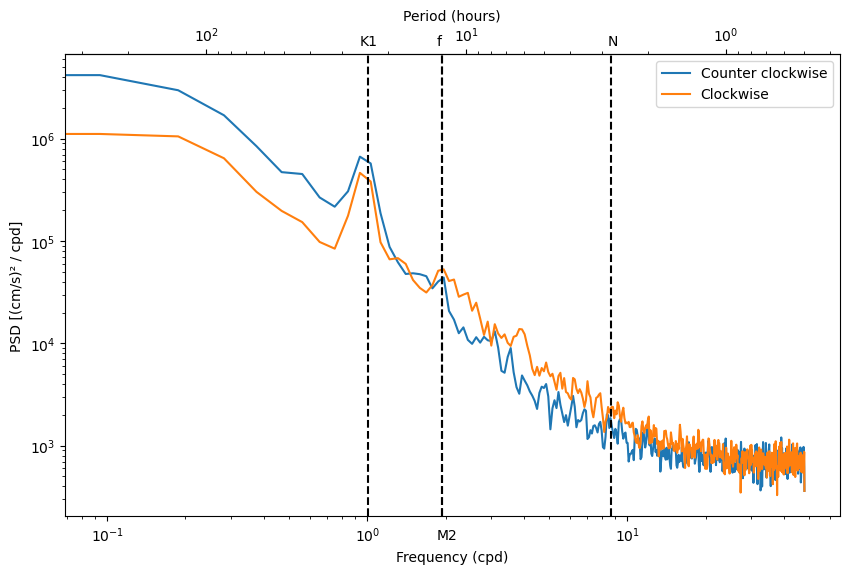

In [9]:
fig = plt.figure(figsize=(10,6))
plt.loglog(freq * 86400, S_ccw, label='Counter clockwise')
plt.loglog(freq * 86400, S_cw,  label='Clockwise')
# plt.loglog(freq * 86400, (S_ccw + S_cw), label='Total')
plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

# Grab the current axis to add the secondary axis
ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f

def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
plt.axvline(1.9323, color='k',label='M2',ls='--')
plt.axvline(1.0027, color='k',label='K1',ls='--')
plt.axvline(1e-4*86400, color='k',label='N',ls='--')
plt.text(0.7, 1.02, "N", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, 1.02, "f", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, -0.05, "M2", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.38, 1.02, "K1", transform=plt.gca().transAxes, fontsize=10, zorder=1)

Text(0.38, 1.02, 'K1')

C:\Users\mblan\AppData\Local\Temp\ipykernel_54016\2558768422.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


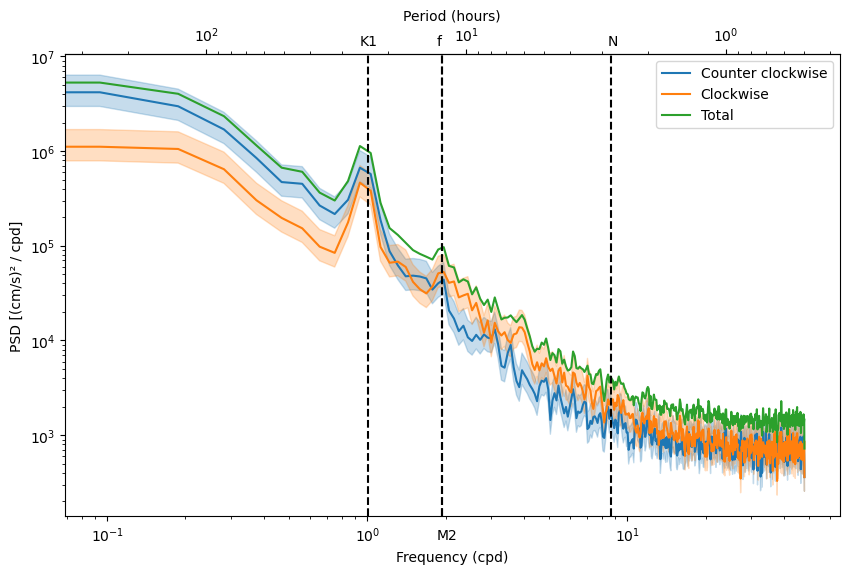

In [10]:
# compute spectra + CI first
# freq, Suu, Svv, Cuv = auto_cross_spectra(u, v, fs, nperseg=nperseg, noverlap=0)
# S_ccw, S_cw = rotary_components(Suu, Svv, Cuv)

# dof, L = dof_welch(n=len(u), nperseg=nperseg, noverlap=0)
# S_ccw_lo, S_ccw_hi = spectra_chi2_ci(S_ccw, dof)
# S_cw_lo, S_cw_hi = spectra_chi2_ci(S_cw, dof)

fig = plt.figure(figsize=(10,6))

freq_cpd = freq * 86400  # compute once, reuse for lines + shading

l1, = plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.fill_between(freq_cpd, S_ccw_lo, S_ccw_hi, color=l1.get_color(), alpha=0.25)

l2, = plt.loglog(freq_cpd, S_cw, label='Clockwise')
plt.fill_between(freq_cpd, S_cw_lo, S_cw_hi, color=l2.get_color(), alpha=0.25)

plt.loglog(freq_cpd, (S_ccw + S_cw), label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f

def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
plt.axvline(1.9323, color='k', label='M2', ls='--')
plt.axvline(1.0027, color='k', label='K1', ls='--')
plt.axvline(1e-4*86400, color='k', label='N', ls='--')
plt.text(0.7, 1.02, "N", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, 1.02, "f", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.48, -0.05, "M2", transform=plt.gca().transAxes, fontsize=10, zorder=1)
plt.text(0.38, 1.02, "K1", transform=plt.gca().transAxes, fontsize=10, zorder=1)

In [11]:
S_total = S_ccw + S_cw

C:\Users\mblan\AppData\Local\Temp\ipykernel_54016\2797038303.py:17: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


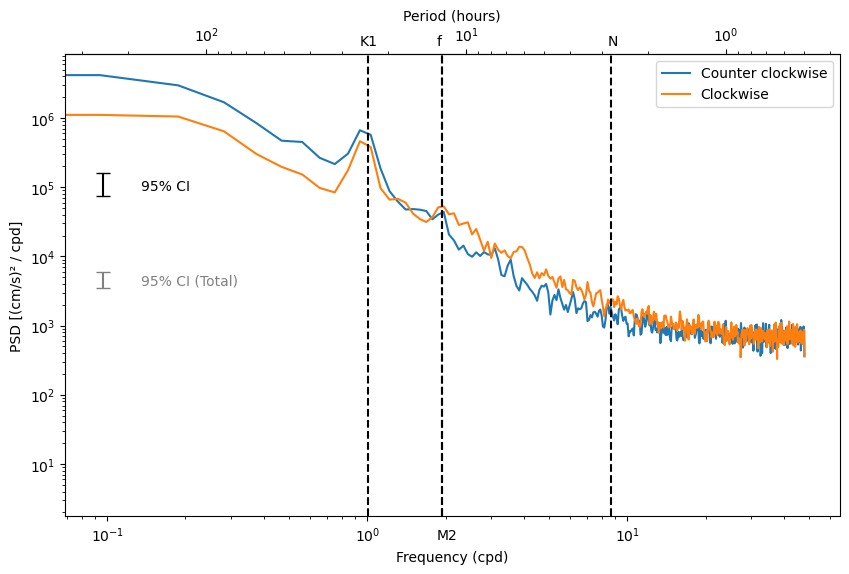

In [12]:
fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

In [13]:
# calculate rotary coefficient and ellipse orientation 
Cr = rotary_power_spectra.rotary_coefficient(S_ccw,S_cw)

In [14]:
sigma = np.arange(10e-2, 10e1, 0.01)
Cr_theory = rotary_power_spectra.rotary_coefficient_theory(sigma,-f_inertial)

In [15]:
f_inertial

np.float64(1.937140660071021)

In [16]:
Cr_theory

array([-0.10297055, -0.11320442, -0.12342033, ..., -0.03873989,
       -0.03873602, -0.03873215], shape=(9990,))

In [17]:
theta = rotary_power_spectra.ellipse_orientation(Suu,Svv,Cuv)

Text(0.5, 0, 'Freqeuncy [cpd]')

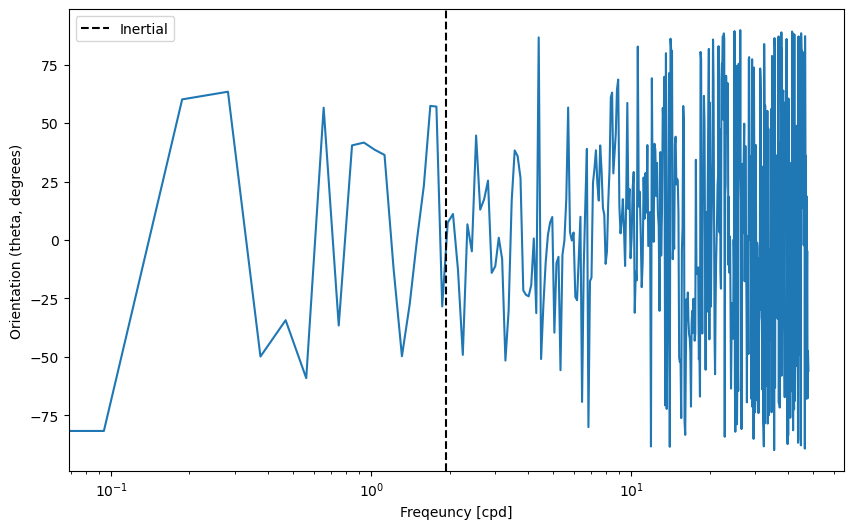

In [18]:
plt.figure(figsize=(10,6))
plt.semilogx(freq*86400, theta)

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
# plt.axvline(1.9323, color='r',label='M2',ls='--')
# plt.axvline(1.0027, color='b',label='K1',ls='--')
# plt.axhline(0,ls='--',color='k')
plt.legend()
plt.ylabel('Orientation (theta, degrees)')
plt.xlabel('Freqeuncy [cpd]')

Text(0.5, 0, 'Freqeuncy [cpd]')

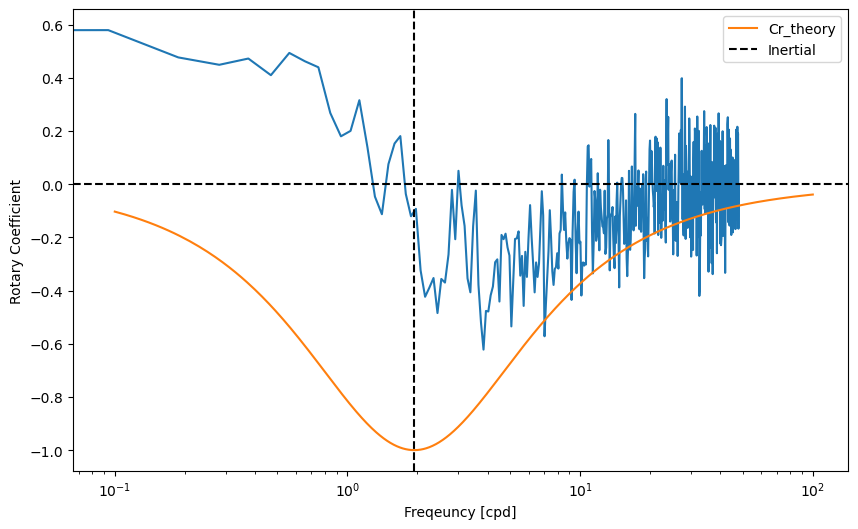

In [19]:
plt.figure(figsize=(10,6))
plt.semilogx(freq*86400, Cr)
plt.semilogx(sigma, Cr_theory,label='Cr_theory')

plt.axvline(f_inertial, color='k', ls='--', label='Inertial')
plt.axhline(0, color='k', ls='--')
# plt.axvline(1.9323, color='r',label='M2',ls='--')
# plt.axvline(1.0027, color='b',label='K1',ls='--')
# plt.axhline(0,ls='--',color='k')
plt.legend()
plt.ylabel('Rotary Coefficient')
plt.xlabel('Freqeuncy [cpd]')

### Seasonal Spectra 

In [20]:
# time slices for seasonal averages 
MAM = slice('2018-03','2018-05')
JJA = slice('2018-06','2018-08')
SON = slice('2018-09','2018-11')
DJF = slice('2018-12','2019-01')  # note only december data here 



In [21]:
MAM_subset = vel.sel(time=MAM)
JJA_subset = vel.sel(time=JJA)
SON_subset = vel.sel(time=SON)
DJF_subset = vel.sel(time=DJF)

In [22]:
len(MAM_subset.time), len(JJA_subset.time), len(SON_subset.time), len(DJF_subset.time)

(7776, 8832, 8736, 3266)

In [68]:
nperseg = len(DJF_subset.time)//2

In [69]:
nperseg

1633

In [70]:
2 ** int(np.log2(nperseg))

1024

In [71]:
nperseg = 2 ** int(np.log2(nperseg))

In [72]:
nperseg

1024

In [73]:
# # MAM SPECTRA 
# freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(MAM_subset.u, MAM_subset.v, fs, nperseg=nperseg, noverlap=0)
# S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

# dof, L = rotary_power_spectra.dof_welch(n=len(MAM_subset.u), nperseg=nperseg, noverlap=0)
# S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
# S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

# S_total = S_ccw + S_cw

In [74]:
%matplotlib widget

Text(0.5, 1.0, 'MAM Spectra')

C:\Users\mblan\AppData\Local\Temp\ipykernel_54016\1163513702.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


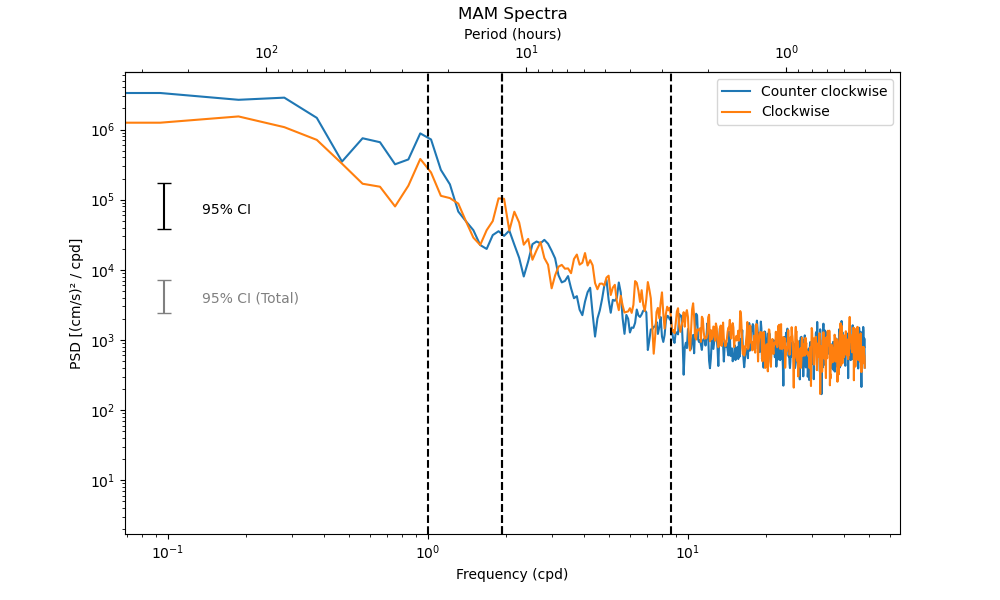

In [75]:
# -------------------- MAM SPECTRA --------------------------------
# nperseg = len(MAM_subset.time)/4

freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(MAM_subset.u, MAM_subset.v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(MAM_subset.u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

S_total = S_ccw + S_cw

# ------------------- PLOTTING ----------------------------------

fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
# plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
# plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

plt.title('MAM Spectra')

Text(0.5, 1.0, 'JJA Spectra')

C:\Users\mblan\AppData\Local\Temp\ipykernel_54016\137673942.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


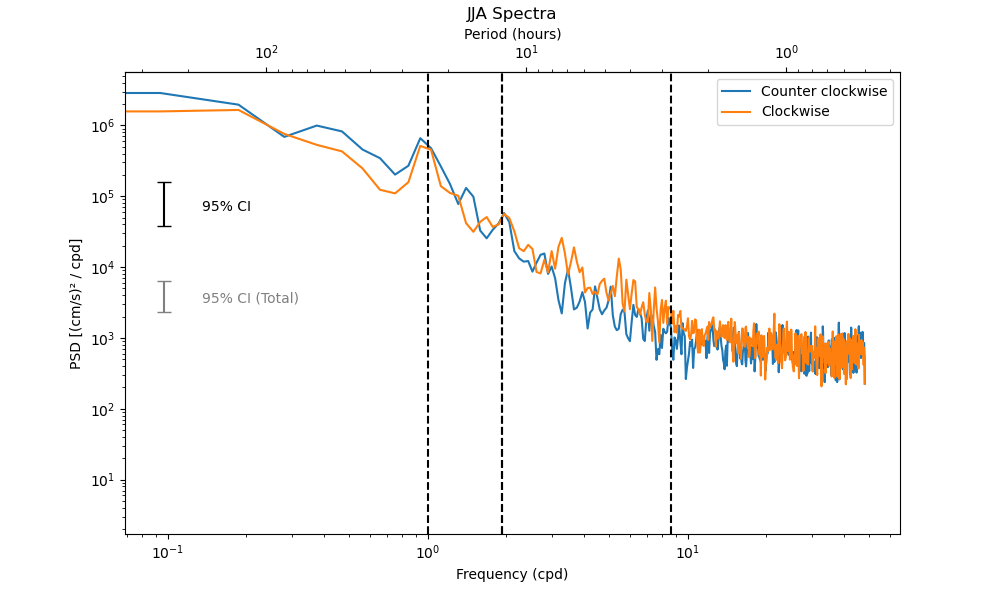

In [76]:
# -------------------- JJA SPECTRA --------------------------------
# nperseg = len(JJA_subset.time)/4

freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(JJA_subset.u, JJA_subset.v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(JJA_subset.u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

S_total = S_ccw + S_cw

# ------------------- PLOTTING ----------------------------------

fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
# plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
# plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

plt.title('JJA Spectra')

Text(0.5, 1.0, 'SON Spectra')

C:\Users\mblan\AppData\Local\Temp\ipykernel_54016\2146110324.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


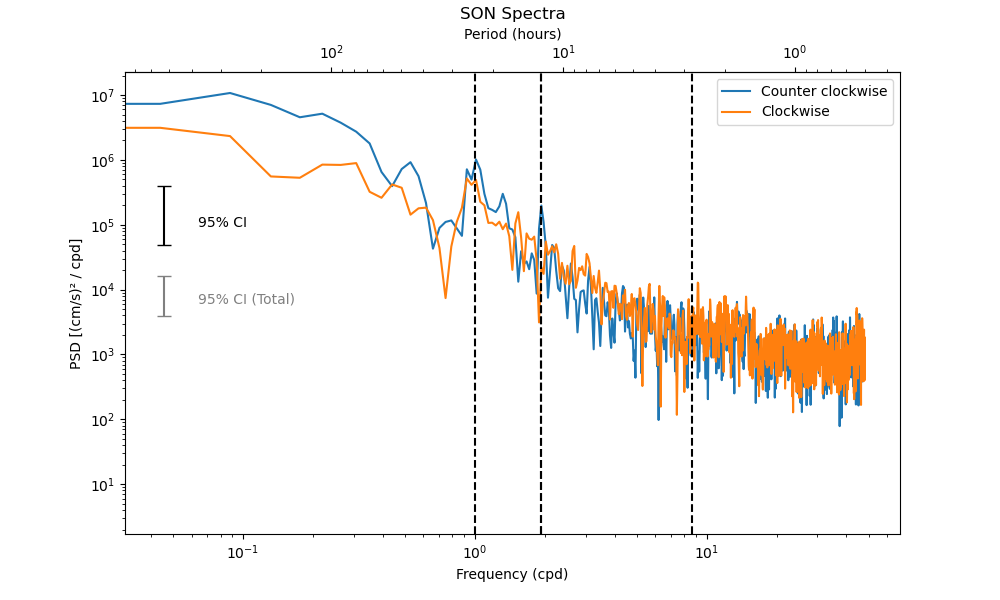

In [77]:
# -------------------- SON SPECTRA --------------------------------
nperseg = len(SON_subset.time)/4

freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(SON_subset.u, SON_subset.v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(SON_subset.u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

S_total = S_ccw + S_cw

# ------------------- PLOTTING ----------------------------------

fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
# plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
# plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

plt.title('SON Spectra')

Text(0.5, 1.0, 'DJF Spectra')

C:\Users\mblan\AppData\Local\Temp\ipykernel_54016\2722115822.py:31: RuntimeWarning: divide by zero encountered in divide
  return 24 / t


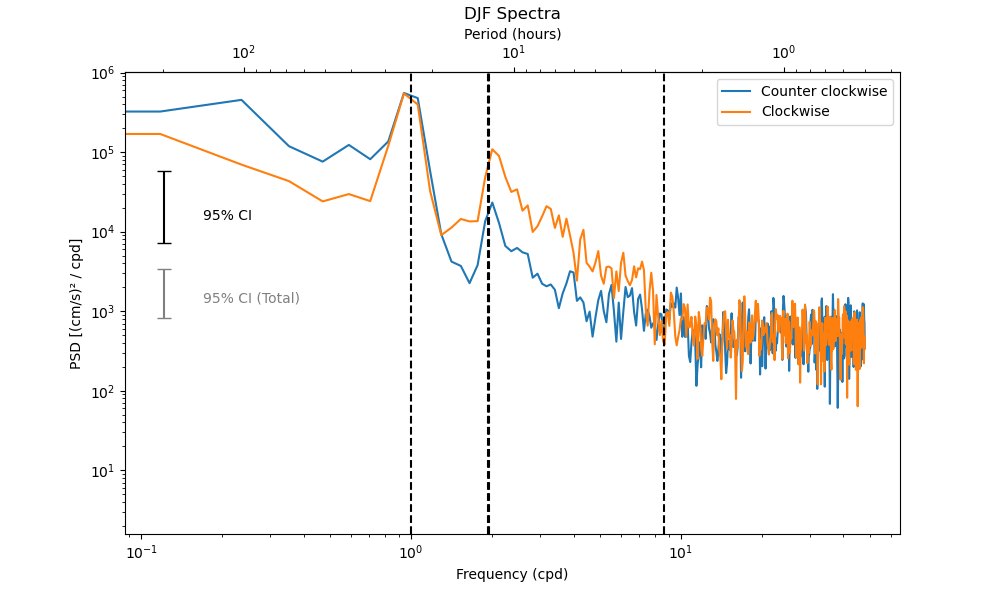

In [78]:
# -------------------- DJF SPECTRA --------------------------------
nperseg = len(DJF_subset.time)/4

freq, Suu, Svv, Cuv = rotary_power_spectra.auto_cross_spectra(DJF_subset.u, DJF_subset.v, fs, nperseg=nperseg, noverlap=0)
S_ccw, S_cw = rotary_power_spectra.rotary_components(Suu, Svv, Cuv)

dof, L = rotary_power_spectra.dof_welch(n=len(DJF_subset.u), nperseg=nperseg, noverlap=0)
S_ccw_lo, S_ccw_hi = rotary_power_spectra.spectra_chi2_ci(S_ccw, dof)
S_cw_lo, S_cw_hi = rotary_power_spectra.spectra_chi2_ci(S_cw, dof)

S_total = S_ccw + S_cw

# ------------------- PLOTTING ----------------------------------

fig = plt.figure(figsize=(10,6))
freq_cpd = freq * 86400

plt.loglog(freq_cpd, S_ccw, label='Counter clockwise')
plt.loglog(freq_cpd, S_cw, label='Clockwise')
# plt.loglog(freq_cpd, S_total, label='Total')

plt.legend()
plt.xlabel('Frequency (cpd)')
plt.ylabel('PSD [(cm/s)² / cpd]')

ax = plt.gca()

def cpd_to_hours(f):
    return 24 / f
def hours_to_cpd(t):
    return 24 / t

secax = ax.secondary_xaxis('top', functions=(cpd_to_hours, hours_to_cpd))
secax.set_xlabel('Period (hours)')

plt.axvline(f_inertial, color='k', ls='--')
plt.axvline(1.9323, color='k', ls='--')
plt.axvline(1.0027, color='k', ls='--')
plt.axvline(1e-4*86400, color='k', ls='--')
# plt.text(0.7, 1.02, "N", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, 1.02, "f", transform=ax.transAxes, fontsize=10)
# plt.text(0.48, -0.05, "M2", transform=ax.transAxes, fontsize=10)
# plt.text(0.38, 1.02, "K1", transform=ax.transAxes, fontsize=10)

# CI brackets -- individual components (CCW/CW share the same dof)
f_lo, f_hi = rotary_power_spectra.chi2_ci_multiplier(dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo, f_hi, x_frac=0.05, y_frac=0.6, label='95% CI', color='k')

# CI bracket -- total spectrum (narrower, double the dof)
f_lo_tot, f_hi_tot = rotary_power_spectra.chi2_ci_multiplier(2 * dof)
rotary_power_spectra.add_ci_bracket(ax, f_lo_tot, f_hi_tot, x_frac=0.05, y_frac=0.5, label='95% CI (Total)', color='gray')

plt.title('DJF Spectra')

In [79]:
dof

8.0

In [81]:
welch?

Signature:
welch(
    x,
    fs=1.0,
    window='hann_periodic',
    nperseg=None,
    noverlap=None,
    nfft=None,
    detrend='constant',
    return_onesided=True,
    scaling='density',
    axis=-1,
    average='mean',
)
Docstring:
Estimate power spectral density using Welch's method.

Welch's method [1]_ computes an estimate of the power spectral
density by dividing the data into overlapping segments, computing a
modified periodogram for each segment and averaging the
periodograms.

Parameters
----------
x : array_like
    Time series of measurement values
fs : float, optional
    Sampling frequency of the `x` time series. Defaults to 1.0.
window : str or tuple or array_like, optional
    Desired window to use. If `window` is a string or tuple, it is
    passed to `get_window` to generate the window values, which are
    DFT-even by default. See `get_window` for a list of windows and
    required parameters. If `window` is array_like it will be used
    directly as the window and 